# Exploratory Data Analysis — Instagram Engagement Dataset

**Dataset:** 378 Instagram posts from 5 Indian beverage brands (Coca-Cola India, Pepsi India, Red Bull India, Sprite India, Thums Up).  
**Goal:** Understand the distribution of engagement metrics, identify patterns across brands and media types, and justify feature engineering decisions made in `train.ipynb`.

---

## Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Posts per Brand and Media Type](#3-posts-per-brand-and-media-type)
4. [Engagement Metric Distributions](#4-engagement-metric-distributions)
5. [Engagement by Brand](#5-engagement-by-brand)
6. [Engagement by Media Type](#6-engagement-by-media-type)
7. [Collab vs Non-Collab Posts](#7-collab-vs-non-collab-posts)
8. [Reel Duration vs Engagement](#8-reel-duration-vs-engagement)
9. [Posting Time Patterns](#9-posting-time-patterns)
10. [Caption & Hashtag Signals](#10-caption--hashtag-signals)
11. [Correlation Heatmap](#11-correlation-heatmap)
12. [Tier Label Distribution (EDA-style)](#12-tier-label-distribution-eda-style)
13. [Brand × Media Summary Table](#13-brand--media-summary-table)

In [ ]:
# 1. Setup & Data Loading
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

In [15]:
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

# Load dataset
with open('assignment-dataset.json') as f:
    raw = json.load(f)

rows = []
for item in raw:
    d = item['data']
    mc = d.get('metadata_content', {})
    ps = d.get('profile_stats', {})
    eng = d.get('engagements', {})
    rows.append({
        'id': d.get('id'),
        'brand': ps.get('username'),
        'followers': ps.get('followers'),
        'media_name': mc.get('media_name'),
        'duration': mc.get('duration'),
        'caption': mc.get('caption', ''),
        'created_at': mc.get('created_at'),
        'is_collab': mc.get('is_collaborated_post', False),
        'num_collaborators': len(mc.get('collaborators', [])),
        'likes': eng.get('likes', 0),
        'views': eng.get('views', 0),
        'comments': eng.get('comments', 0),
        'shares': eng.get('shares', 0),
        'engagement_rate': eng.get('engagement_rate', 0),
    })

df = pd.DataFrame(rows)
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['hour'] = df['created_at'].dt.hour
df['dayofweek'] = df['created_at'].dt.day_name()
df['caption_len'] = df['caption'].str.len()
df['hashtag_count'] = df['caption'].str.count('#')

print(df.shape)
df.head(3)


(378, 18)


,id,brand,followers,media_name,duration,caption,created_at,is_collab,num_collaborators,likes,views,comments,shares,engagement_rate,hour,dayofweek,caption_len,hashtag_count
0,DUxE-r8AuL7,sprite_india,170642,reel,30,Garmi ke dar se dekhi horror film? \nSahi se c...,2026-02-15 05:30:22+00:00,True,2,438223,54141956,1164,3484,0.817981,5,Sunday,88,0
1,DU8JuEeDc7f,sprite_india,170642,reel,13,Sreeleela = enters. The temperature = drops. \...,2026-02-19 12:43:53+00:00,True,1,175084,3261101,854,5209,5.554780,12,Thursday,125,2
2,DXQ15NNAfxo,sprite_india,170642,reel,20,Taptapi garmi mein ho rahe late. \nUpar se sig...,2026-04-18 06:38:45+00:00,False,0,11147,1844281,45,116,0.613139,6,Saturday,94,0


## 3. Posts per Brand and Media Type

Check dataset balance — how many posts per brand, and how many per media format (reel / post / album).

In [16]:
# Basic info + missing values
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.describe()


id                                object
brand                             object
followers                          int64
media_name                        object
duration                           int64
caption                           object
created_at           datetime64[ns, UTC]
is_collab                           bool
num_collaborators                  int64
likes                              int64
views                              int64
comments                           int64
shares                             int64
engagement_rate                  float64
hour                               int32
dayofweek                         object
caption_len                        int64
hashtag_count                      int64
dtype: object

Missing values:
 id                   0
brand                0
followers            0
media_name           0
duration             0
caption              0
created_at           0
is_collab            0
num_collaborators    0
likes                0


,followers,duration,num_collaborators,likes,views,comments,shares,engagement_rate,hour,caption_len,hashtag_count
count,378.000000,378.000000,378.000000,378.000000,3.780000e+02,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000
mean,357416.230159,26.589947,0.616402,60656.828042,1.327076e+07,263.531746,2472.708995,6.112142,11.082011,157.317460,2.711640
std,195399.438388,26.808657,0.776612,105652.165796,7.908594e+07,740.817450,7759.939965,15.558393,3.349832,143.268347,2.050793
min,150402.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000736,3.000000,20.000000,0.000000
25%,170642.000000,7.000000,0.000000,2475.250000,1.733275e+04,21.000000,0.000000,0.634257,9.000000,89.250000,0.000000
50%,298373.000000,20.000000,0.000000,18982.500000,4.294455e+05,51.000000,102.500000,2.280260,11.500000,122.000000,3.000000
75%,634008.000000,38.750000,1.000000,71557.750000,3.421102e+06,154.000000,855.250000,6.047928,13.000000,180.750000,4.000000
max,634008.000000,205.000000,4.000000,868211.000000,1.067655e+09,6748.000000,79346.000000,157.093742,20.000000,1984.000000,7.000000


## 4. Engagement Metric Distributions

Log-scale histograms for likes, views, comments, shares, and engagement rate. Log scale is needed because engagement distributions are heavily right-skewed — a few viral posts dominate.

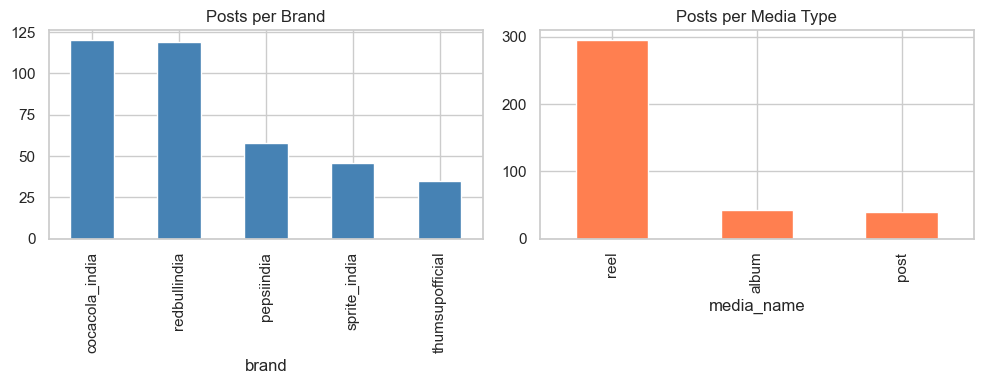

In [17]:
# Posts per brand and media type
fig, axes = plt.subplots(1, 2)
df['brand'].value_counts().plot(kind='bar', ax=axes[0], title='Posts per Brand', color='steelblue')
df['media_name'].value_counts().plot(kind='bar', ax=axes[1], title='Posts per Media Type', color='coral')
plt.tight_layout(); plt.show()


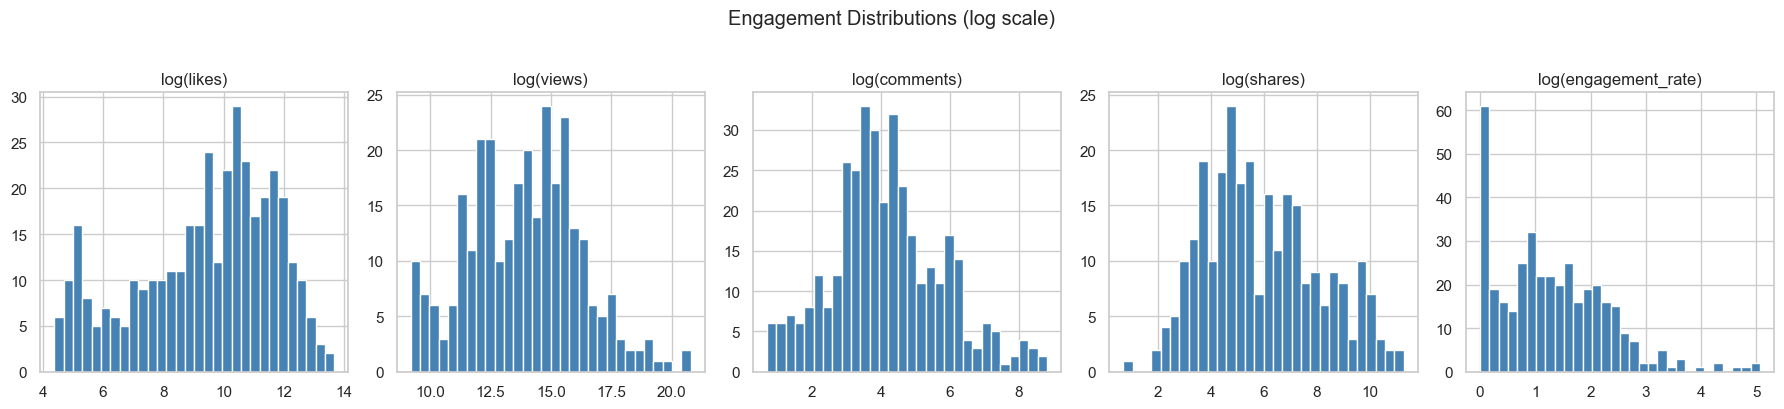

In [18]:
# Engagement metric distributions (log scale)
metrics = ['likes', 'views', 'comments', 'shares', 'engagement_rate']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, metrics):
    df[col].replace(0, np.nan).dropna().apply(np.log1p).hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'log({col})')
plt.suptitle('Engagement Distributions (log scale)', y=1.02)
plt.tight_layout(); plt.show()


## 5. Engagement by Brand

Compare median engagement rate and view counts across brands using box plots. Log scale on views to handle outliers.

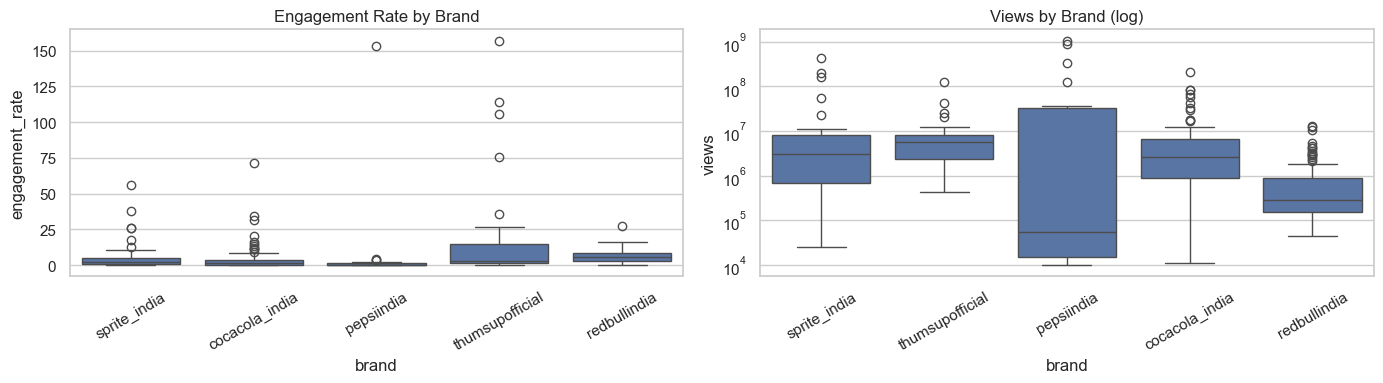

In [19]:
# Engagement by brand
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x='brand', y='engagement_rate', ax=axes[0])
axes[0].set_title('Engagement Rate by Brand'); axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df[df['views'] > 0], x='brand', y='views', ax=axes[1])
axes[1].set_yscale('log'); axes[1].set_title('Views by Brand (log)'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


## 6. Engagement by Media Type

Compare likes, views, and engagement rate across reel / post / album formats. Reels dominate view counts; posts tend to have higher engagement rates relative to follower base.

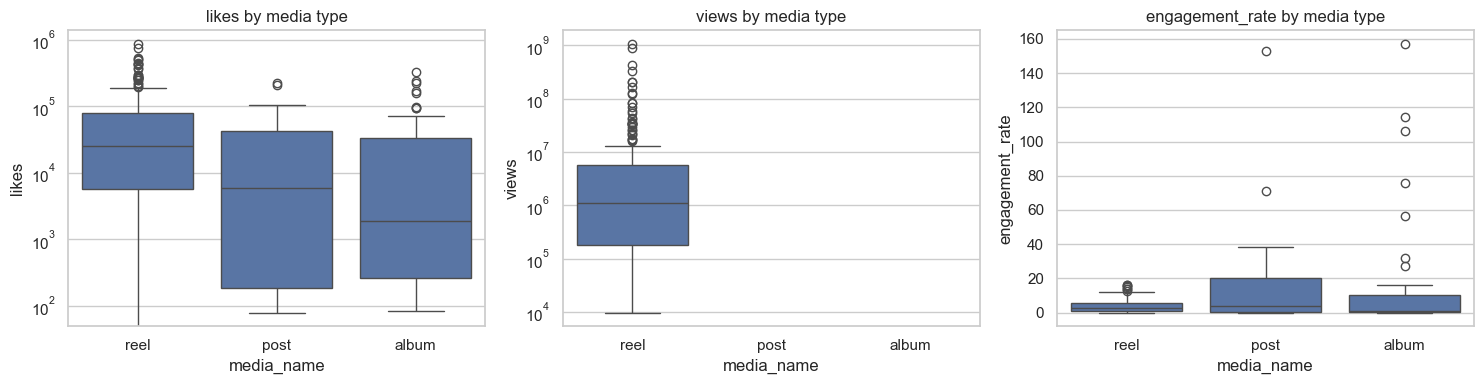

In [20]:
# Engagement by media type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['likes', 'views', 'engagement_rate']):
    sns.boxplot(data=df, x='media_name', y=col, ax=ax)
    if col != 'engagement_rate':
        ax.set_yscale('log')
    ax.set_title(f'{col} by media type')
plt.tight_layout(); plt.show()


## 7. Collab vs Non-Collab Posts

Does tagging a collaborator (influencer post) correlate with higher engagement? Compare median metrics.

Median engagement — collab vs non-collab:
              likes     views  engagement_rate
is_collab                                    
False      12485.0  155524.0         1.821682
True       28971.0  738733.0         2.712157


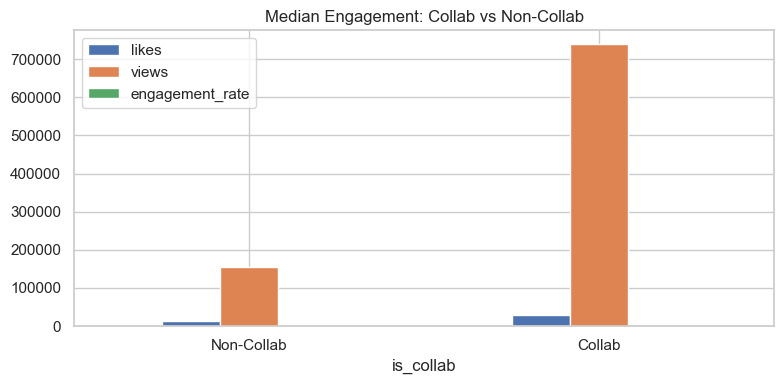

In [21]:
# Collab vs non-collab
collab_stats = df.groupby('is_collab')[['likes', 'views', 'engagement_rate']].median()
print("Median engagement — collab vs non-collab:\n", collab_stats)
collab_stats.plot(kind='bar', figsize=(8, 4), title='Median Engagement: Collab vs Non-Collab')
plt.xticks([0,1], ['Non-Collab', 'Collab'], rotation=0); plt.tight_layout(); plt.show()


## 8. Reel Duration vs Engagement

Scatter plots of reel duration (seconds) against engagement rate and log(views). Justifies the `duration_bin` feature in the training pipeline.

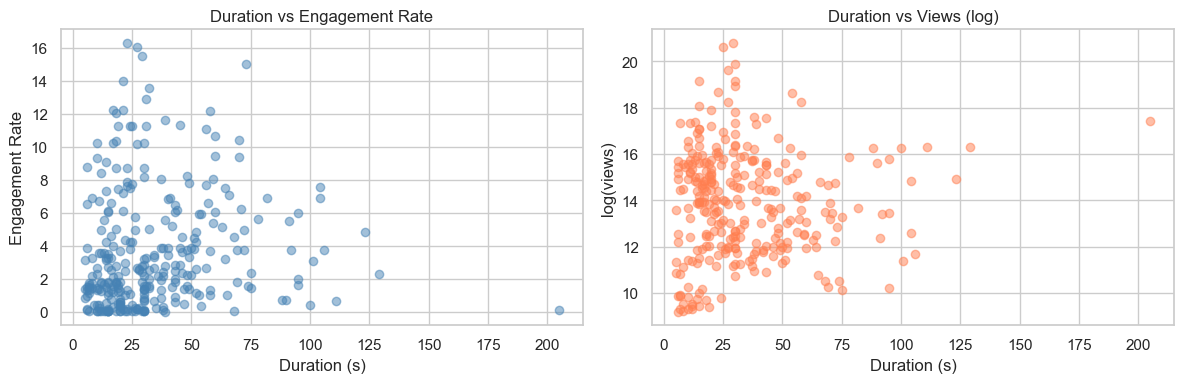

                 duration  engagement_rate     views
duration         1.000000         0.097458 -0.029618
engagement_rate  0.097458         1.000000 -0.172757
views           -0.029618        -0.172757  1.000000


In [22]:
# Reel duration vs engagement (reels only)
reels = df[df['media_name'] == 'reel'].dropna(subset=['duration'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(reels['duration'], reels['engagement_rate'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Duration (s)'); axes[0].set_ylabel('Engagement Rate'); axes[0].set_title('Duration vs Engagement Rate')
axes[1].scatter(reels['duration'], np.log1p(reels['views']), alpha=0.5, color='coral')
axes[1].set_xlabel('Duration (s)'); axes[1].set_ylabel('log(views)'); axes[1].set_title('Duration vs Views (log)')
plt.tight_layout(); plt.show()
print(reels[['duration', 'engagement_rate', 'views']].corr())


## 9. Posting Time Patterns

Does posting hour or day of week correlate with engagement? Justifies `post_hour`, `post_dow`, `hour_bucket`, and `is_weekend` features.

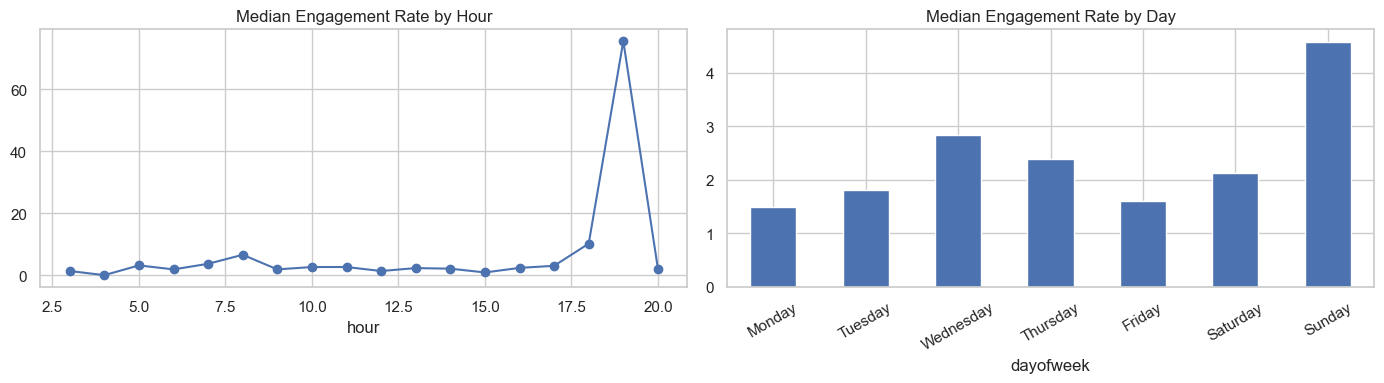

In [23]:
# Posting time patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby('hour')['engagement_rate'].median().plot(ax=axes[0], marker='o', title='Median Engagement Rate by Hour')
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('dayofweek')['engagement_rate'].median().reindex(day_order).plot(kind='bar', ax=axes[1], title='Median Engagement Rate by Day')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


## 10. Caption Length & Hashtag Signals

Do longer captions or more hashtags drive more engagement? Scatter plots + Pearson correlation. Justifies `caption_len`, `hashtag_count`, and `emoji_density` features.

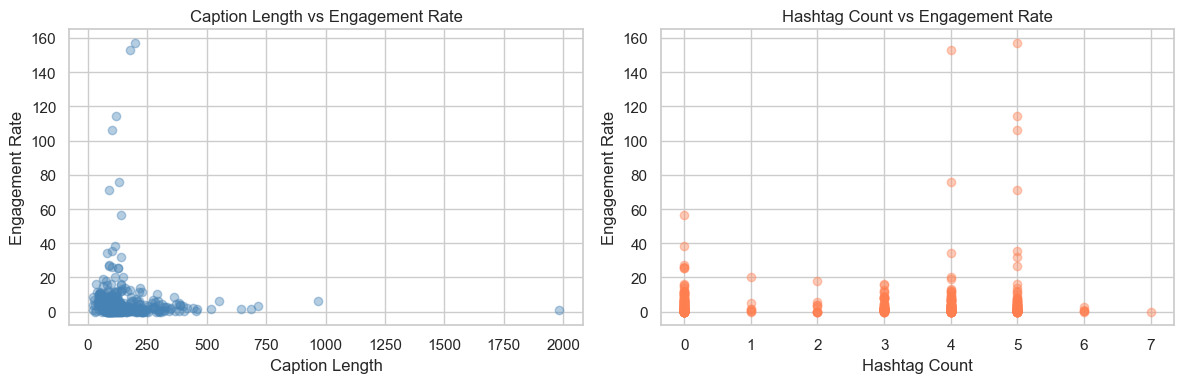

                 caption_len  hashtag_count  engagement_rate     likes  \
caption_len         1.000000       0.245248        -0.056074  0.008229   
hashtag_count       0.245248       1.000000         0.064701  0.150931   
engagement_rate    -0.056074       0.064701         1.000000  0.225909   
likes               0.008229       0.150931         0.225909  1.000000   
views               0.020592       0.097987        -0.061552  0.368212   

                    views  
caption_len      0.020592  
hashtag_count    0.097987  
engagement_rate -0.061552  
likes            0.368212  
views            1.000000  


In [24]:
# Caption length & hashtag count vs engagement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['caption_len'], df['engagement_rate'], alpha=0.4, color='steelblue')
axes[0].set_xlabel('Caption Length'); axes[0].set_ylabel('Engagement Rate'); axes[0].set_title('Caption Length vs Engagement Rate')
axes[1].scatter(df['hashtag_count'], df['engagement_rate'], alpha=0.4, color='coral')
axes[1].set_xlabel('Hashtag Count'); axes[1].set_ylabel('Engagement Rate'); axes[1].set_title('Hashtag Count vs Engagement Rate')
plt.tight_layout(); plt.show()
print(df[['caption_len','hashtag_count','engagement_rate','likes','views']].corr())


## 11. Correlation Heatmap

Full Pearson correlation matrix across all numeric features. Helps identify multicollinearity and which raw metrics most strongly correlate with engagement rate.

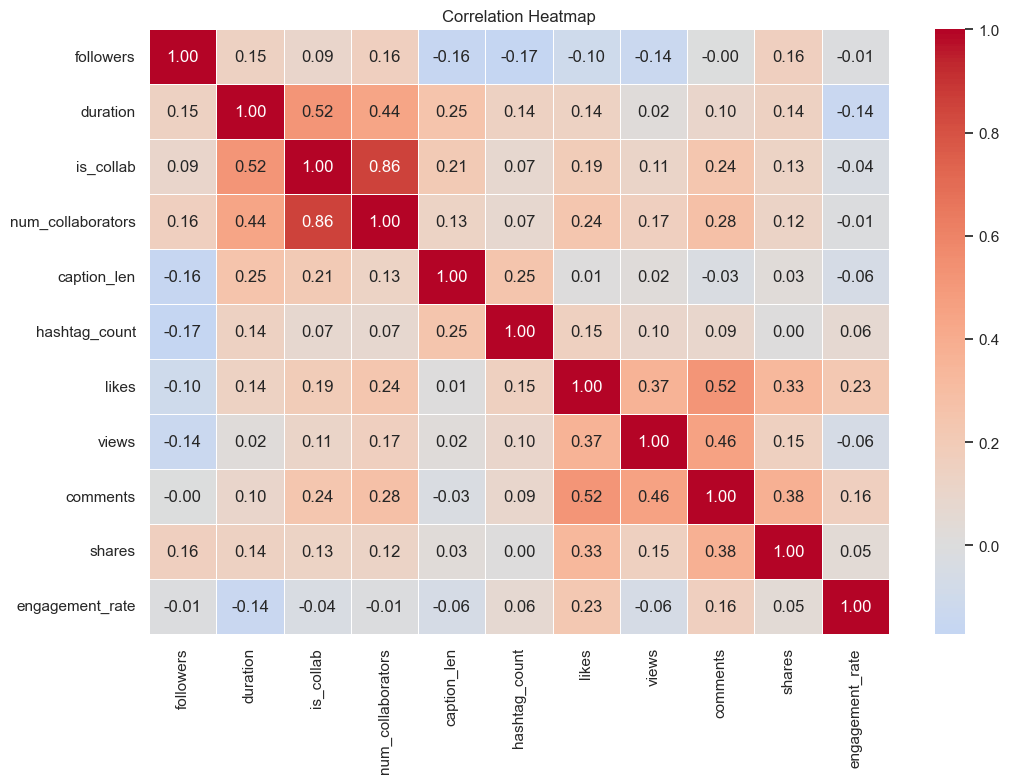

In [25]:
# Correlation heatmap (numeric features)
num_cols = ['followers', 'duration', 'is_collab', 'num_collaborators',
            'caption_len', 'hashtag_count', 'likes', 'views', 'comments', 'shares', 'engagement_rate']
corr = df[num_cols].assign(is_collab=df['is_collab'].astype(int)).corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap'); plt.tight_layout(); plt.show()


## 12. Tier Label Distribution (EDA-style)

Assign performance tiers within each brand × media group using within-group percentile rank (equal thirds: LOW / MEDIUM / HIGH) and a now-deprecated VIRAL bucket. The final training pipeline uses a 3-class scheme — this cell shows how tier frequencies look across media types.

tier
LOW       125
MEDIUM    119
HIGH       90
VIRAL      44
Name: count, dtype: int64


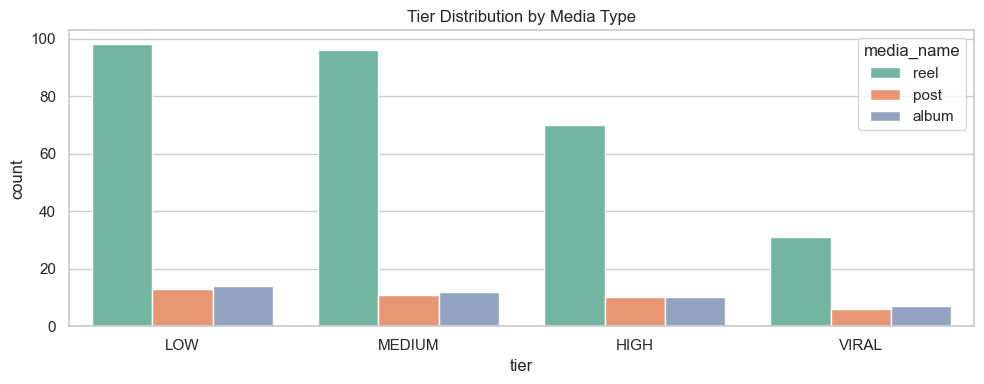

In [26]:
# Performance tier labeling (percentile within brand x media_name)
def label_tier(group):
    q = group['engagement_rate'].quantile([0.33, 0.66, 0.90])
    def classify(v):
        if v >= q[0.90]: return 'VIRAL'
        elif v >= q[0.66]: return 'HIGH'
        elif v >= q[0.33]: return 'MEDIUM'
        else: return 'LOW'
    group['tier'] = group['engagement_rate'].apply(classify)
    return group

df = df.groupby(['brand', 'media_name'], group_keys=False).apply(label_tier)
print(df['tier'].value_counts())
sns.countplot(data=df, x='tier', order=['LOW','MEDIUM','HIGH','VIRAL'],
              hue='media_name', palette='Set2')
plt.title('Tier Distribution by Media Type'); plt.tight_layout(); plt.show()


## 13. Brand × Media Type Summary Table

Aggregate statistics (post count, median ER, median likes/views, collab rate) per brand × media combination — useful for understanding coverage and data density before training.

In [27]:
# Summary stats per brand x media type
summary = df.groupby(['brand', 'media_name']).agg(
    count=('id', 'count'),
    median_eng_rate=('engagement_rate', 'median'),
    median_likes=('likes', 'median'),
    median_views=('views', 'median'),
    collab_pct=('is_collab', 'mean'),
).round(2)
summary


count  median_eng_rate  median_likes  \
brand           media_name                                         
cocacola_india  album          13             4.02       11988.0   
                post           10             6.95       20659.5   
                reel           97             1.57       29363.0   
pepsiindia      album          11             0.10         152.0   
                post           17             0.11         162.0   
                reel           30             1.31         848.5   
redbullindia    album          10             1.05        6632.0   
                post            1             0.80        5043.0   
                reel          108             5.92       15196.5   
sprite_india    album           5             0.12         202.0   
                post            7            17.76       30226.0   
                reel           34             1.80       57970.5   
thumsupofficial album           4           110.21      229180.5   
                post            5            25.43       52856.0   
                reel           26             1.98      104703.5   

                            median_views  collab_pct  
brand           media_name                            
cocacola_india  album                0.0        0.15  
                post                 0.0        0.30  
                reel           2654040.0        0.61  
pepsiindia      album                0.0        0.00  
                post                 0.0        0.18  
                reel             53829.0        0.30  
redbullindia    album                0.0        0.20  
                post                 0.0        0.00  
                reel            282569.0        0.54  
sprite_india    album                0.0        0.40  
                post                 0.0        0.00  
                reel           3109645.0        0.76  
thumsupofficial album                0.0        0.00  
                post                 0.0        0.20  
                reel           5669388.5        0.38